In [26]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver


In [27]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)  # Initialize the ChatGroq model

In [28]:
from langgraph.graph.message import add_messages

#state 
class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [29]:
checkpointer = MemorySaver()  # Initialize the MemorySaver checkpoint

In [30]:
def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    response = llm.invoke(messages)

    # response store state
    return {'messages': [response]}

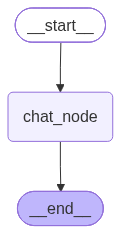

In [31]:
graph = StateGraph(ChatState)

graph.add_node('chat_node' ,chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)
chat_bot = graph.compile(checkpointer=checkpointer)  # Compile the graph with the MemorySaver checkpoint
chat_bot

In [32]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of india')]
}

chat_bot.invoke(initial_state)['messages'][-1].content
 #here we are taking the last message from the list of messages in the state and returning its content.

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [33]:
thread_id = '1'
while True:
    user_input = input("User: ")
    print("User:", user_input)
    if user_input.lower() in ['exit', 'quit','bye']:
        print("Exiting the chat.")
        break   
    config = {
        'configurable': {'thread_id': thread_id}
    }
    response = chat_bot.invoke({
        'messages': [HumanMessage(content=user_input)]
    }, config=config)
    print("Bot:", response['messages'][-1].content)


User: hello
Bot: Hello! How can I assist you today?
User: your name
Bot: I’m ChatGPT, your AI assistant. How can I help you today?
User: which api u are using
Bot: I’m powered by a large language model created by OpenAI. It’s designed to understand and generate text across a wide range of topics, so I can help answer questions, brainstorm ideas, draft content, and more. Let me know what you’d like to discuss!
User: i am kartik
Bot: Nice to meet you, Kartik! How can I assist you today?
User: what is my name
Bot: Your name is Kartik.
User: bye
Exiting the chat.


In [34]:
chat_bot.get_state(config =config)

StateSnapshot(values={'messages': [HumanMessage(content='hello', additional_kwargs={}, response_metadata={}, id='199d13d6-539d-4683-a045-8fc03a7cddb6'), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "hello". We need to respond appropriately. It\'s a simple greeting. We can respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 72, 'total_tokens': 113, 'completion_time': 0.085383316, 'completion_tokens_details': {'reasoning_tokens': 23}, 'prompt_time': 0.002631412, 'prompt_tokens_details': None, 'queue_time': 0.382775995, 'total_time': 0.088014728}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e5b4e54fbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a1217e-b2ee-7a21-a833-deb3ba4da4f4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 41, 'total_tokens'